<a href="https://colab.research.google.com/github/oj3v0ns/MMM/blob/main/MMM_trainer_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_example.html#model-specification



*   EDA
*   OOS vs actual, train vs test





##Setup

In [70]:
#import packages

import warnings

!pip install pymc-marketing pymc-extras

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
from pymc_extras.prior import Prior
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.metrics import r2_score

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100


In [71]:
#load data from github

excel_url = "https://github.com/oj3v0ns/MMM/raw/8a73fc2d8d55fa3b285e169d7dee8aa7211278b7/Project%20Input%20Data%20with%20Spend.xlsx"
data = pd.read_excel(excel_url, sheet_name=0)

# convert date and y variable names to something more universal
data = data.rename(columns={"Accounts Subscriptions": "y"})
data = data.rename(columns={"Date": "date"})

# trend feature
n = data.shape[0]
data["t"] = range(n)

data.head()


,date,y,Google Display Cost,Google Branded Paid Search Cost,TV Cost,Google Generic Paid Search Cost,Influencers Cost,Meta Cost,YouTube Cost,Dates_School_Holidays,Competitors Promotion,Promotion,t
0,2022-01-01,4182.0,5.293500,3580.52,0.000000,5322.2000,0.0,11637.1932,5572.056,0,14.0,14.0,0
1,2022-01-08,5167.5,93.744731,5089.80,0.000000,8332.1816,2094.0,9171.1386,5466.384,6,14.0,14.0,1
2,2022-01-15,6229.0,1.553699,6805.89,6308.571429,11375.9528,1059.0,8847.9300,13711.656,7,14.0,14.0,2
3,2022-01-22,7801.5,240.301070,8085.96,44160.000000,10568.9024,174.0,8113.6578,16921.800,7,14.0,14.0,3
4,2022-01-29,9505.0,1.175135,7761.05,44160.000000,10806.5400,264.0,11027.9868,37302.216,7,14.0,14.0,4


#Define variables

In [21]:
#for scikit learn convention

X = data.drop("y", axis=1)
y = data["y"]

In [22]:
# define channels and controls for convenience

channels = [
    "Google Display Cost",
    "Meta Cost",
    "Google Generic Paid Search Cost",
    "TV Cost",
    "Influencers Cost",
    "Google Branded Paid Search Cost",
    "YouTube Cost",
]

controls = [
    "Dates_School_Holidays",
    "Competitors Promotion",
    "Promotion",
    "t",
]

#Define priors

In [23]:
# view dummy model

dummy_model = MMM(
    date_column="",
    channel_columns=[""],
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
)
dummy_model.default_model_config

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

In [24]:
# comput share of spend as a starting point for media priors

total_spend_per_channel = data[channels].sum(axis=0)
spend_share = total_spend_per_channel / total_spend_per_channel.sum()

n_channels = 7

prior_sigma = n_channels * spend_share.to_numpy()
prior_sigma.tolist()

[0.18836945547545192,
 1.5739825150186304,
 1.4777468876979822,
 0.5101934237645955,
 0.012253444879202584,
 1.273920697506585,
 1.963533575657552]

In [25]:
# integrate media priors into your model configuration

my_model_config = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.2),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.05, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=6)),
}

#Model specification

In [26]:
my_sampler_config = {"progressbar": True}

/usr/local/lib/python3.12/dist-packages/pymc_extras/prior.py:822: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


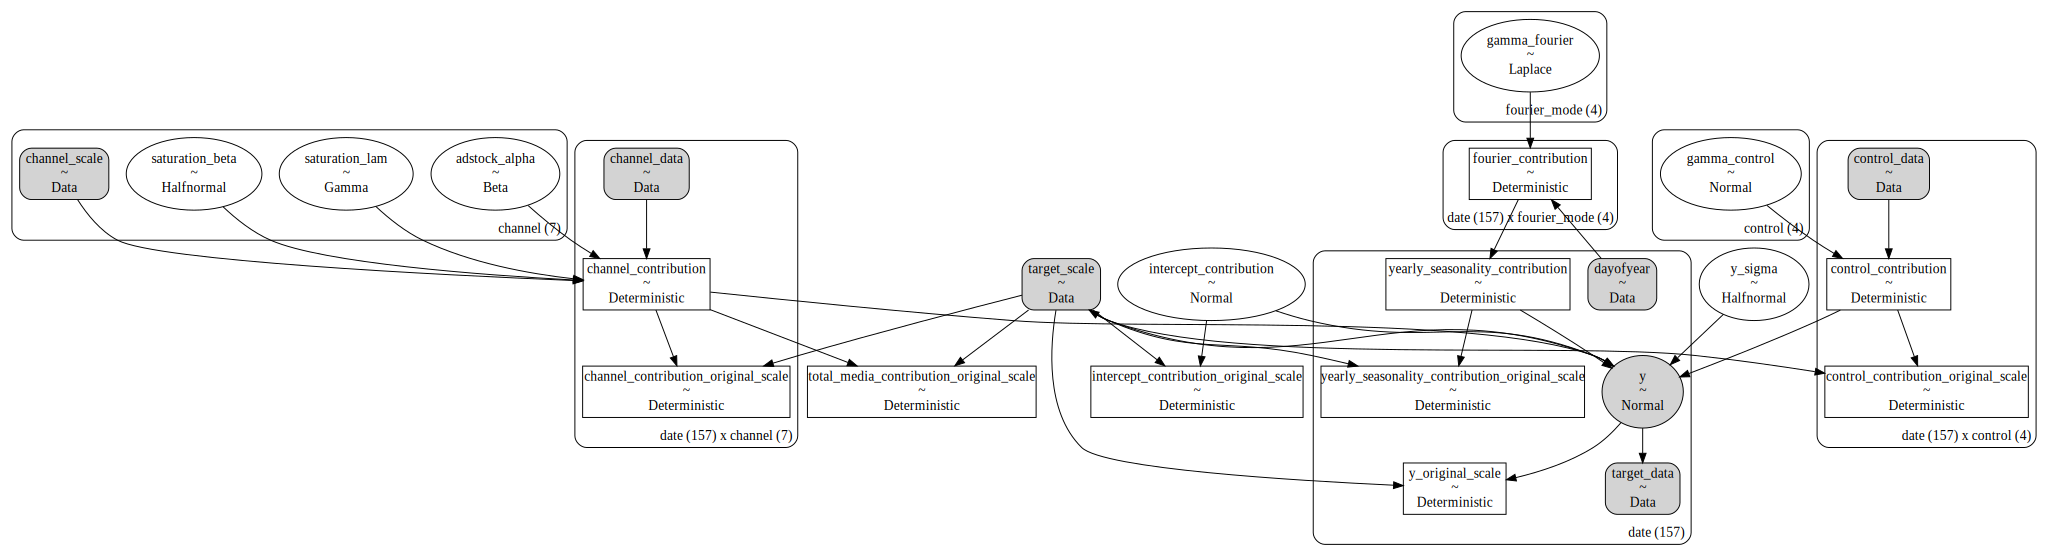

In [27]:
# specify the model based on your model configuration

mmm = MMM(
    model_config=my_model_config,
    sampler_config=my_sampler_config,
    date_column="date", # no need to change
    target_column="y", # no need to change
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    channel_columns=channels, # no need to change
    control_columns=controls, # no need to change
    yearly_seasonality=2,
)

# Build the model and add contribution variables in original scale
mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

pm.model_to_graphviz(mmm.model)

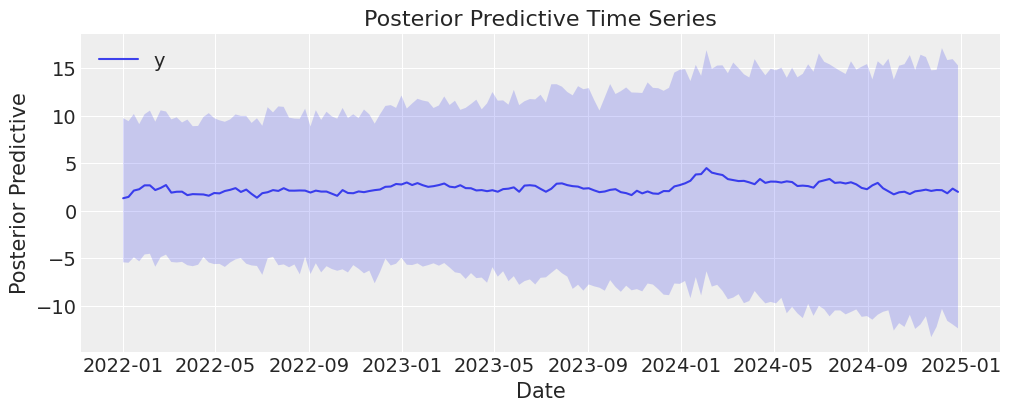

In [28]:
# Generate prior predictive samples

mmm.sample_prior_predictive(X, y, samples=2_000)
fig, axes = mmm.plot.prior_predictive()

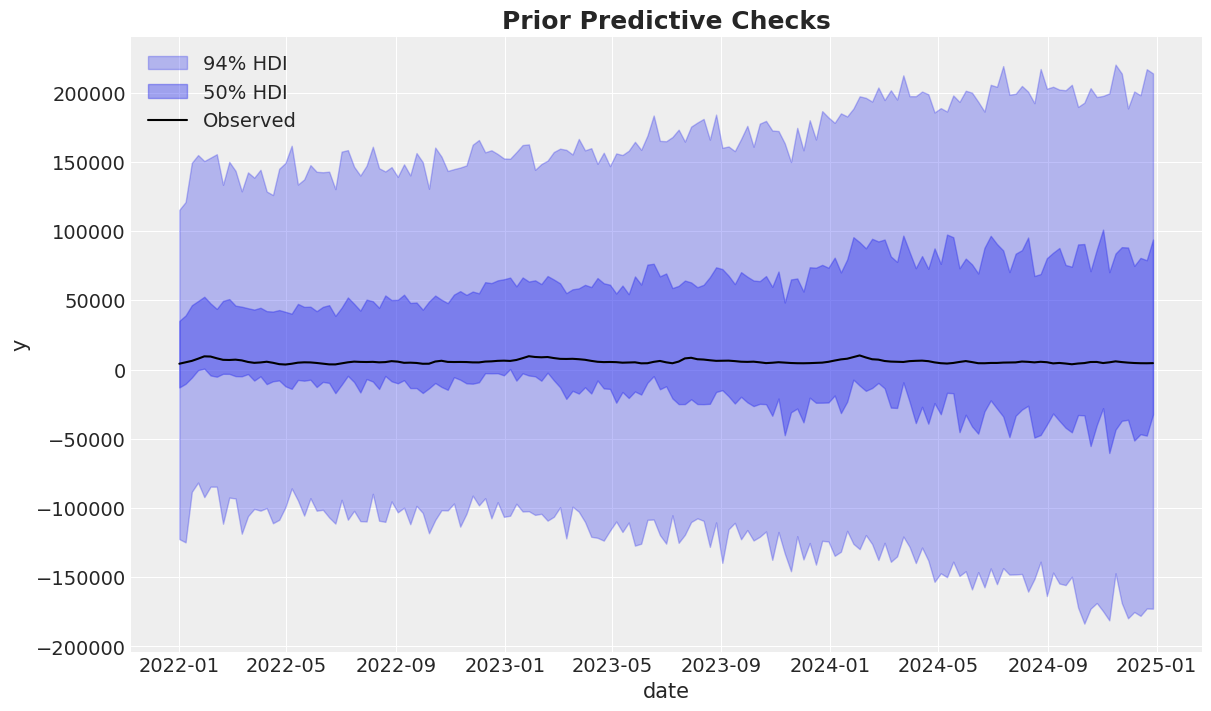

In [30]:
# Custom plot for prior predictive checks

fig, ax = plt.subplots()
for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=mmm.idata["prior"]["y_original_scale"].unstack().transpose(..., "date"),
        smooth=False,
        color="C0",
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.3 + i * 0.1, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )
sns.lineplot(data=data, x="date", y="y", color="black", label="Observed", ax=ax)
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="y")
ax.set_title("Prior Predictive Checks", fontsize=18, fontweight="bold");

#Model fitting

In [31]:
%%time
seed: int = sum(map(ord, "mmm"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

mmm.fit(
    X=X,
    y=y,
    chains=4,
    tune=1_500,
    draws=1_000,
    target_accept=0.9,
    random_seed=rng,
)

Output()

Output()

CPU times: user 11min 15s, sys: 26.5 s, total: 11min 41s
Wall time: 12min 25s


Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

In [33]:
# save the model

mmm.save(fname="model")

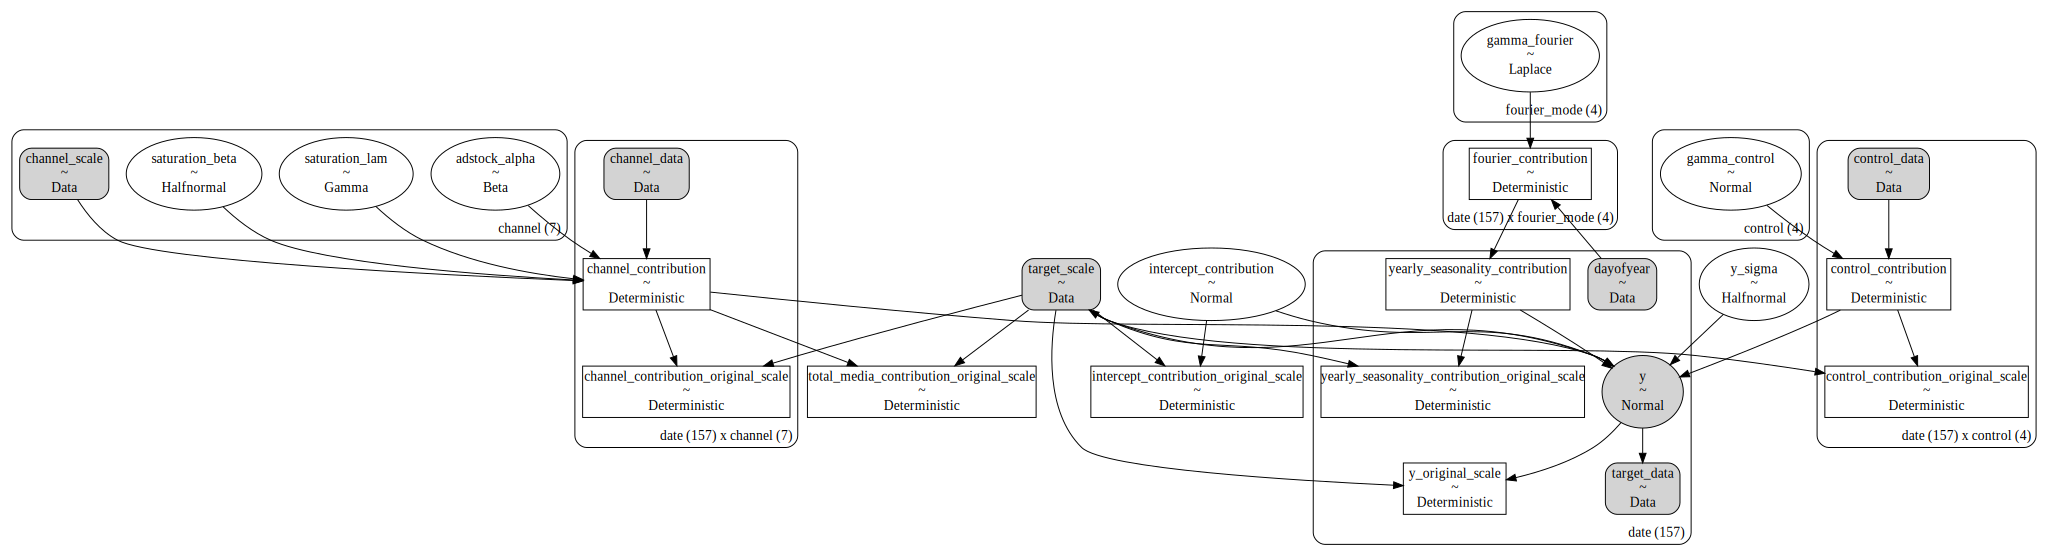

In [34]:
# view the model structure

mmm.graphviz()

In [ ]:
# load the model (if needed)

mmm.load(fname="model")

#Model diagnostics

In [35]:
mmm.table()

                                 Variable  Expression                                  Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                          channel_scale =  Data                                        channel[7]                  
                           target_scale =  Data                                                                    
                           channel_data =  Data                                        date[157] × channel[7]      
                            target_data =  Data                                        date[157]                   
                           control_data =  Data                                        date[157] × control[4]      
                              dayofyear =  Data                                        date[157]                   
                                                                                                                   
                 intercept_contribution ~  Normal(0.5, 0.2)                                                        
                          adstock_alpha ~  Beta(1, 3)                                  channel[7]                  
                         saturation_lam ~  Gamma(3, f())                               channel[7]                  
                        saturation_beta ~  HalfNormal(0, <constant>)                   channel[7]                  
                          gamma_control ~  Normal(0, 0.05)                             control[4]                  
                          gamma_fourier ~  Laplace(0, 0.2)                             fourier_mode[4]             
                                y_sigma ~  HalfNormal(0, 6)                                                        
                                                                                       Parameter count = 31        
                                                                                                                   
                   channel_contribution =  f(saturation_beta, saturation_lam,          date[157] × channel[7]      
                                           adstock_alpha)                                                          
  total_media_contribution_original_scale  f(saturation_beta, saturation_lam,                                      
                                        =  adstock_alpha)                                                          
                   control_contribution =  f(gamma_control)                            date[157] × control[4]      
                   fourier_contribution =  f(gamma_fourier)                            date[157] × fourier_mode[4] 
        yearly_seasonality_contribution =  f(gamma_fourier)                            date[157]                   
    channel_contribution_original_scale =  f(saturation_beta, saturation_lam,          date[157] × channel[7]      
                                           adstock_alpha)                                                          
    control_contribution_original_scale =  f(gamma_control)                            date[157] × control[4]      
  intercept_contribution_original_scale =  f(intercept_contribution)                                               
 yearly_seasonality_contribution_origina…  f(gamma_fourier)                            date[157]                   
                                        =                                                                          
                       y_original_scale =  f(y)                                        date[157]                   
                                                                                                                   
                                      y ~  Normal(f(intercept_contribution,            date[157]                   
                                           gamma_control

In [36]:
# Number of diverging samples

mmm.idata["sample_stats"]["diverging"].sum().item()

0

In [37]:
mmm.fit_result

<xarray.Dataset> Size: 147MB
Dimensions:                                         (chain: 4, draw: 1000,
                                                     channel: 7, control: 4,
                                                     fourier_mode: 4, date: 157)
Coordinates:
  * chain                                           (chain) int64 32B 0 1 2 3
  * draw                                            (draw) int64 8kB 0 1 ... 999
  * channel                                         (channel) <U31 868B 'Goog...
  * control                                         (control) <U21 336B 'Date...
  * fourier_mode                                    (fourier_mode) <U5 80B 's...
  * date                                            (date) datetime64[ns] 1kB ...
Data variables: (12/17)
    adstock_alpha                                   (chain, draw, channel) float64 224kB ...
    gamma_control                                   (chain, draw, control) float64 128kB ...
    gamma_fourier                                   (chain, draw, fourier_mode) float64 128kB ...
    intercept_contribution                          (chain, draw) float64 32kB ...
    saturation_beta                                 (chain, draw, channel) float64 224kB ...
    saturation_lam                                  (chain, draw, channel) float64 224kB ...
    ...                                              ...
    fourier_contribution                            (chain, draw, date, fourier_mode) float64 20MB ...
    intercept_contribution_original_scale           (chain, draw) float64 32kB ...
    total_media_contribution_original_scale         (chain, draw) float64 32kB ...
    y_original_scale                                (chain, draw, date) float64 5MB ...
    yearly_seasonality_contribution                 (chain, draw, date) float64 5MB ...
    yearly_seasonality_contribution_original_scale  (chain, draw, date) float64 5MB ...
Attributes:
    created_at:                 2026-05-08T13:41:51.835831+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              702.5864901542664
    tuning_steps:               1500
    pymc_marketing_version:     0.19.4

In [38]:
# summary of the trace

az.summary(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
adstock_alpha[Google Display Cost],0.212,0.167,0.000,0.521,0.002,0.003,4932.0,2372.0,1.0
adstock_alpha[Meta Cost],0.403,0.242,0.002,0.799,0.005,0.002,2470.0,2340.0,1.0
adstock_alpha[Google Generic Paid Search Cost],0.313,0.136,0.041,0.542,0.002,0.002,3195.0,1604.0,1.0
adstock_alpha[TV Cost],0.580,0.205,0.157,0.902,0.005,0.004,2439.0,1821.0,1.0
adstock_alpha[Influencers Cost],0.251,0.189,0.001,0.607,0.002,0.003,5068.0,2321.0,1.0
adstock_alpha[Google Branded Paid Search Cost],0.241,0.188,0.000,0.587,0.003,0.003,4408.0,2082.0,1.0
adstock_alpha[YouTube Cost],0.124,0.085,0.000,0.269,0.001,0.001,3310.0,1838.0,1.0
gamma_control[Dates_School_Holidays],0.010,0.003,0.005,0.015,0.000,0.000,4244.0,2677.0,1.0
gamma_control[Competitors Promotion],-0.008,0.002,-0.012,-0.005,0.000,0.000,2906.0,2412.0,1.0
gamma_control[Promotion],0.003,0.001,0.001,0.006,0.000,0.000,3652.0,2989.0,1.0


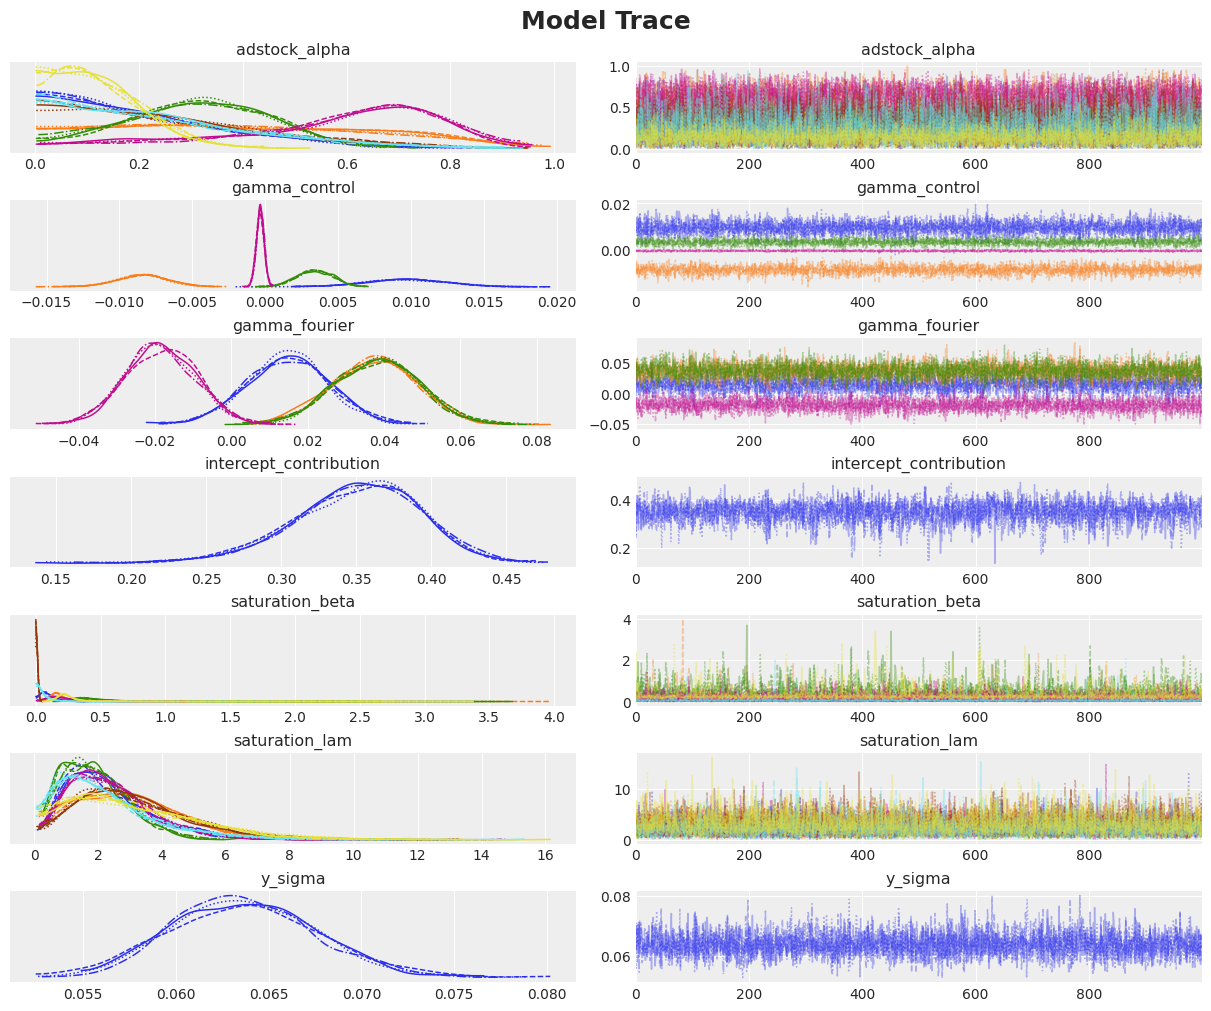

In [39]:
# plot the trace - check for good chain mixing

_ = az.plot_trace(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=18, fontweight="bold");

In [41]:
mmm.sample_posterior_predictive(X=X, random_seed=rng)

Output()

<xarray.Dataset> Size: 10MB
Dimensions:           (date: 157, sample: 4000)
Coordinates:
  * date              (date) datetime64[ns] 1kB 2022-01-01 ... 2024-12-28
  * sample            (sample) object 32kB MultiIndex
  * chain             (sample) int64 32kB 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw              (sample) int64 32kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    y                 (date, sample) float64 5MB 0.3528 0.3491 ... 0.4217 0.499
    y_original_scale  (date, sample) float64 5MB 3.585e+03 ... 5.072e+03
Attributes:
    created_at:                 2026-05-08T13:45:41.066232+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4

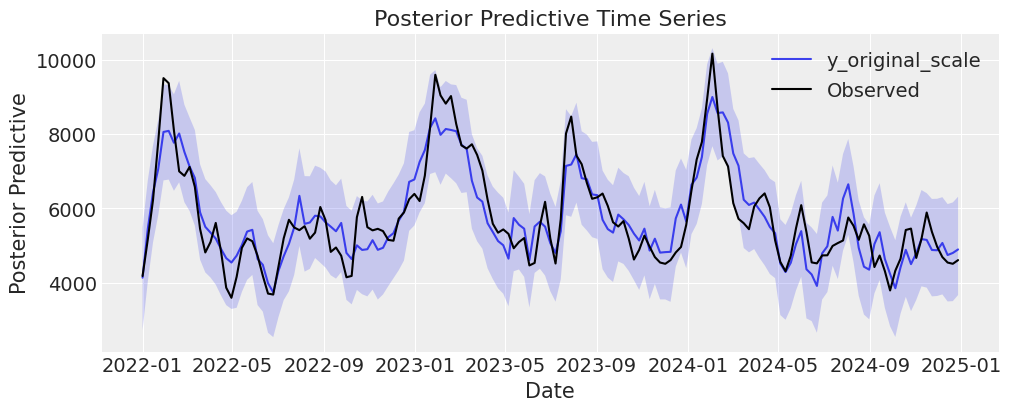

In [42]:
# actual vs predicted

fig, axes = mmm.plot.posterior_predictive(var=["y_original_scale"], hdi_prob=0.94)
sns.lineplot(
    data=data, x="date", y="y", color="black", label="Observed", ax=axes[0][0]
);

In [72]:
# calculate R2 and MAPE

# Get the posterior predictive mean for y_original_scale
y_pred_mean = mmm.idata["posterior_predictive"]["y_original_scale"].mean(dim=["chain", "draw"])

# Calculate R-squared
r_squared = r2_score(y, y_pred_mean)

# Calculate MAPE
mape = np.mean(np.abs((y - y_pred_mean) / y)) * 100

print(f"R-squared (in-sample): {r_squared:.4f}")
print(f"MAPE (in-sample): {mape:.4f}%")

R-squared (in-sample): 0.7945
MAPE (in-sample): 8.3809%


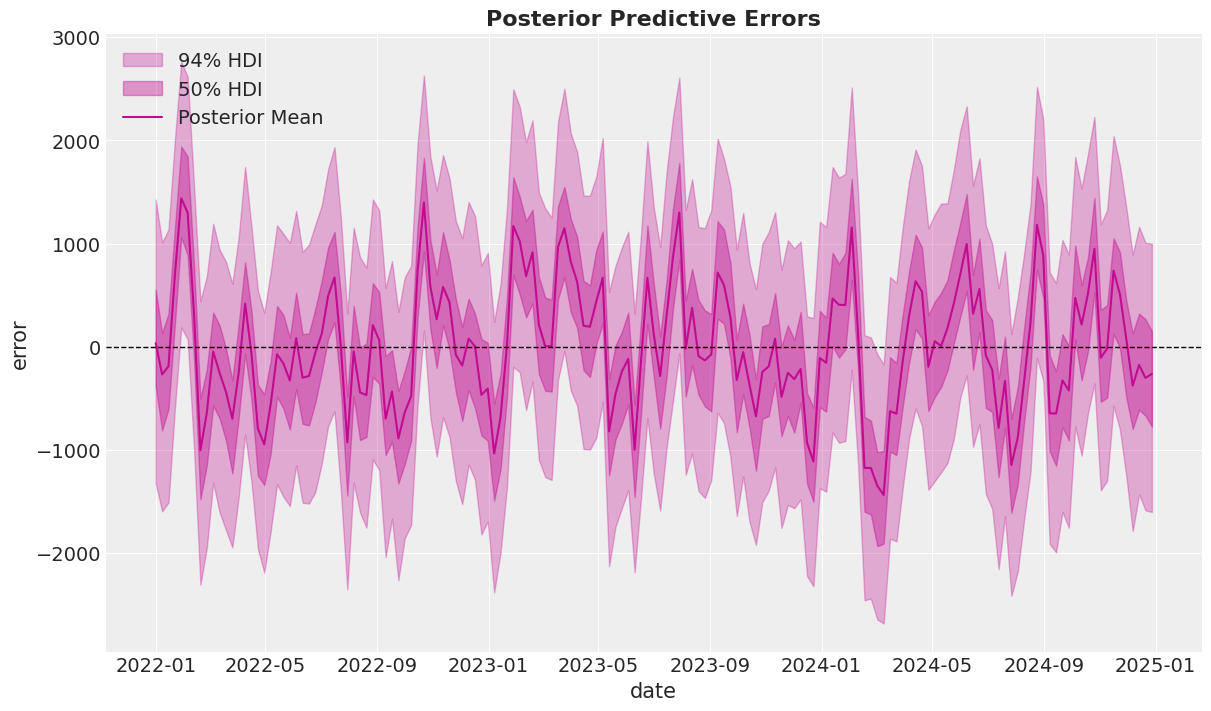

In [43]:
# Compute errors: true - predicted

errors = (
    y.to_numpy()[np.newaxis, np.newaxis, :] - mmm.idata["posterior"]["y_original_scale"]
)

fig, ax = plt.subplots()
for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=errors,
        color="C3",
        smooth=False,
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.3 + i * 0.1, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )
sns.lineplot(
    x=mmm.model.coords["date"],
    y=errors.mean(dim=("chain", "draw")),
    color="C3",
    label="Posterior Mean",
    ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.legend()
ax.set(xlabel="date", ylabel="error")
ax.set_title("Posterior Predictive Errors", fontsize=16, fontweight="bold");

#Model insights

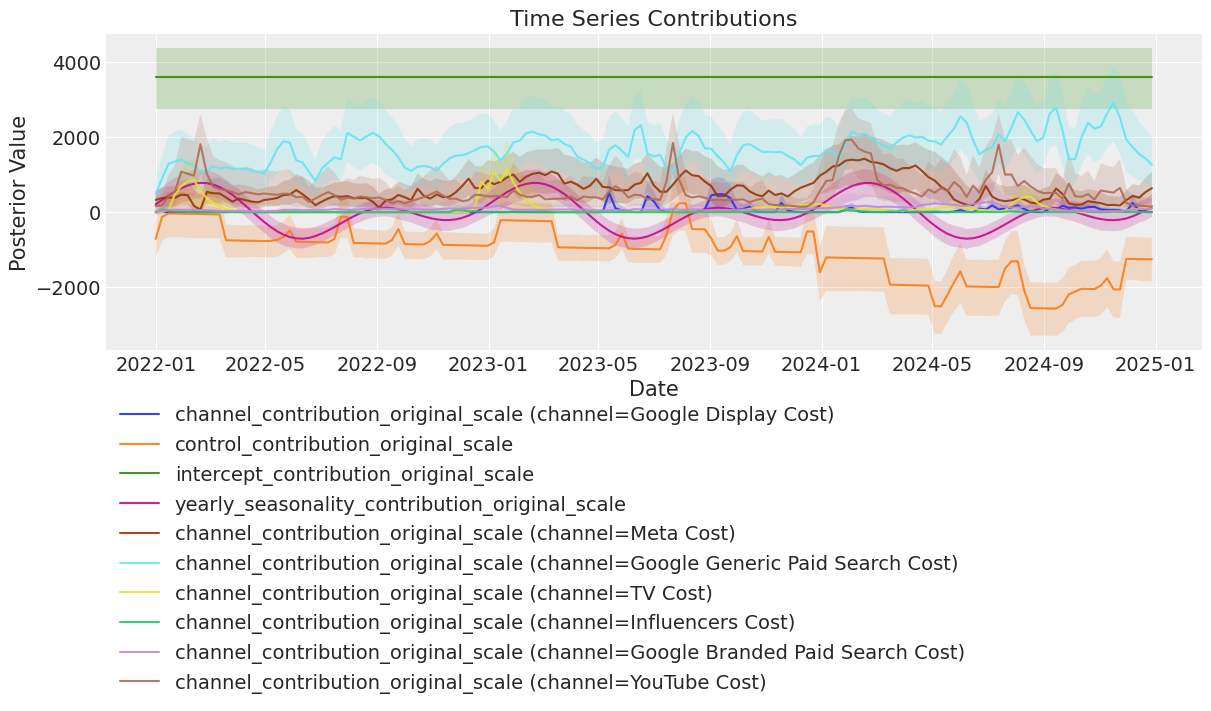

In [60]:
# Component contributions (original scale)

fig, ax = mmm.plot.contributions_over_time(
    var=[
        "channel_contribution_original_scale",
        "control_contribution_original_scale",
        "intercept_contribution_original_scale",
        "yearly_seasonality_contribution_original_scale",
    ],
    dims={"channel": channels},
    combine_dims=True,
    hdi_prob=0.94,
    figsize=(12, 7),
)


legend = ax[0, 0].get_legend()
legend.set_bbox_to_anchor((0.8, -0.12))

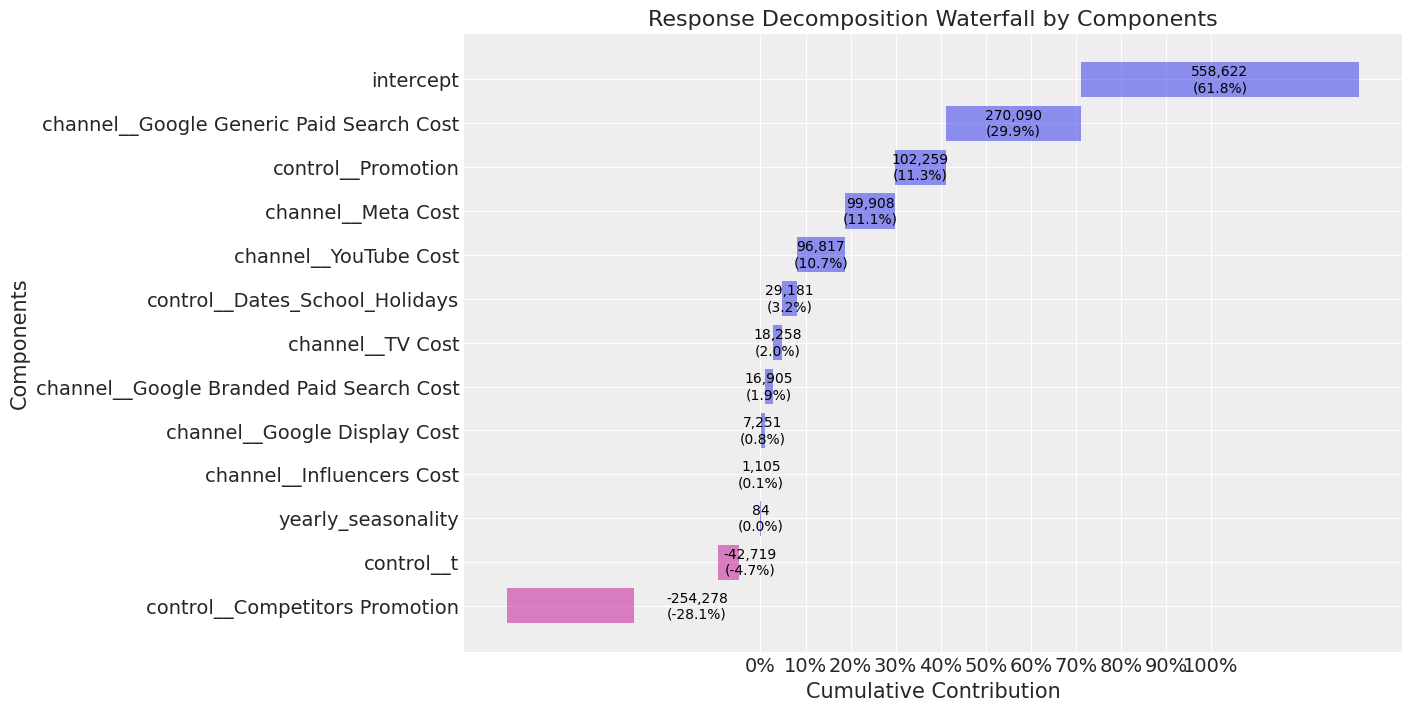

In [45]:
#waterfall plot (whole modelling period)

mmm.plot.waterfall_components_decomposition();

In [46]:
# weekly trend for mean contribution

mmm.compute_mean_contributions_over_time()

,date,Google Display Cost,Meta Cost,Google Generic Paid Search Cost,TV Cost,Influencers Cost,Google Branded Paid Search Cost,YouTube Cost,Dates_School_Holidays,Competitors Promotion,Promotion,t,yearly_seasonality,intercept
0,2022-01-01,0.127268,338.198878,522.736839,0.000000,0.000000,28.786328,198.782375,0.000000,-1201.161061,483.471591,0.000000,215.282958,3558.101172
1,2022-01-08,2.276733,386.290673,952.460234,0.000000,76.330051,46.263940,218.508464,587.541885,-1201.161061,483.471591,-3.488427,327.621642,3558.101172
2,2022-01-15,0.449932,410.941001,1346.152171,67.387768,65.709889,63.581055,500.886907,685.465533,-1201.161061,483.471591,-6.976854,438.604415,3558.101172
3,2022-01-22,5.908779,409.381294,1400.735897,484.390578,30.192147,77.228368,632.644486,685.465533,-1201.161061,483.471591,-10.465280,542.192656,3558.101172
4,2022-01-29,1.118971,493.253875,1445.983974,697.545927,25.067774,78.131869,1164.608022,685.465533,-1201.161061,483.471591,-13.953707,632.515006,3558.101172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,2024-11-30,11.330977,337.261192,1972.308435,48.027226,2.931571,65.390591,293.249916,0.000000,-1201.161061,483.471591,-530.240870,-163.379324,3558.101172
153,2024-12-07,262.185124,452.436758,1779.000636,74.930441,1.015369,84.848574,221.959028,0.000000,-1201.161061,483.471591,-533.729297,-106.931239,3558.101172
154,2024-12-14,51.461216,413.153770,1597.625185,91.962507,0.462705,100.145266,212.083494,0.000000,-1201.161061,483.471591,-537.217724,-31.340341,3558.101172
155,2024-12-21,15.785569,556.506379,1483.930368,103.393593,0.241687,102.426100,192.353895,0.000000,-1201.161061,483.471591,-540.706150,60.440868,3558.101172


#Media insights

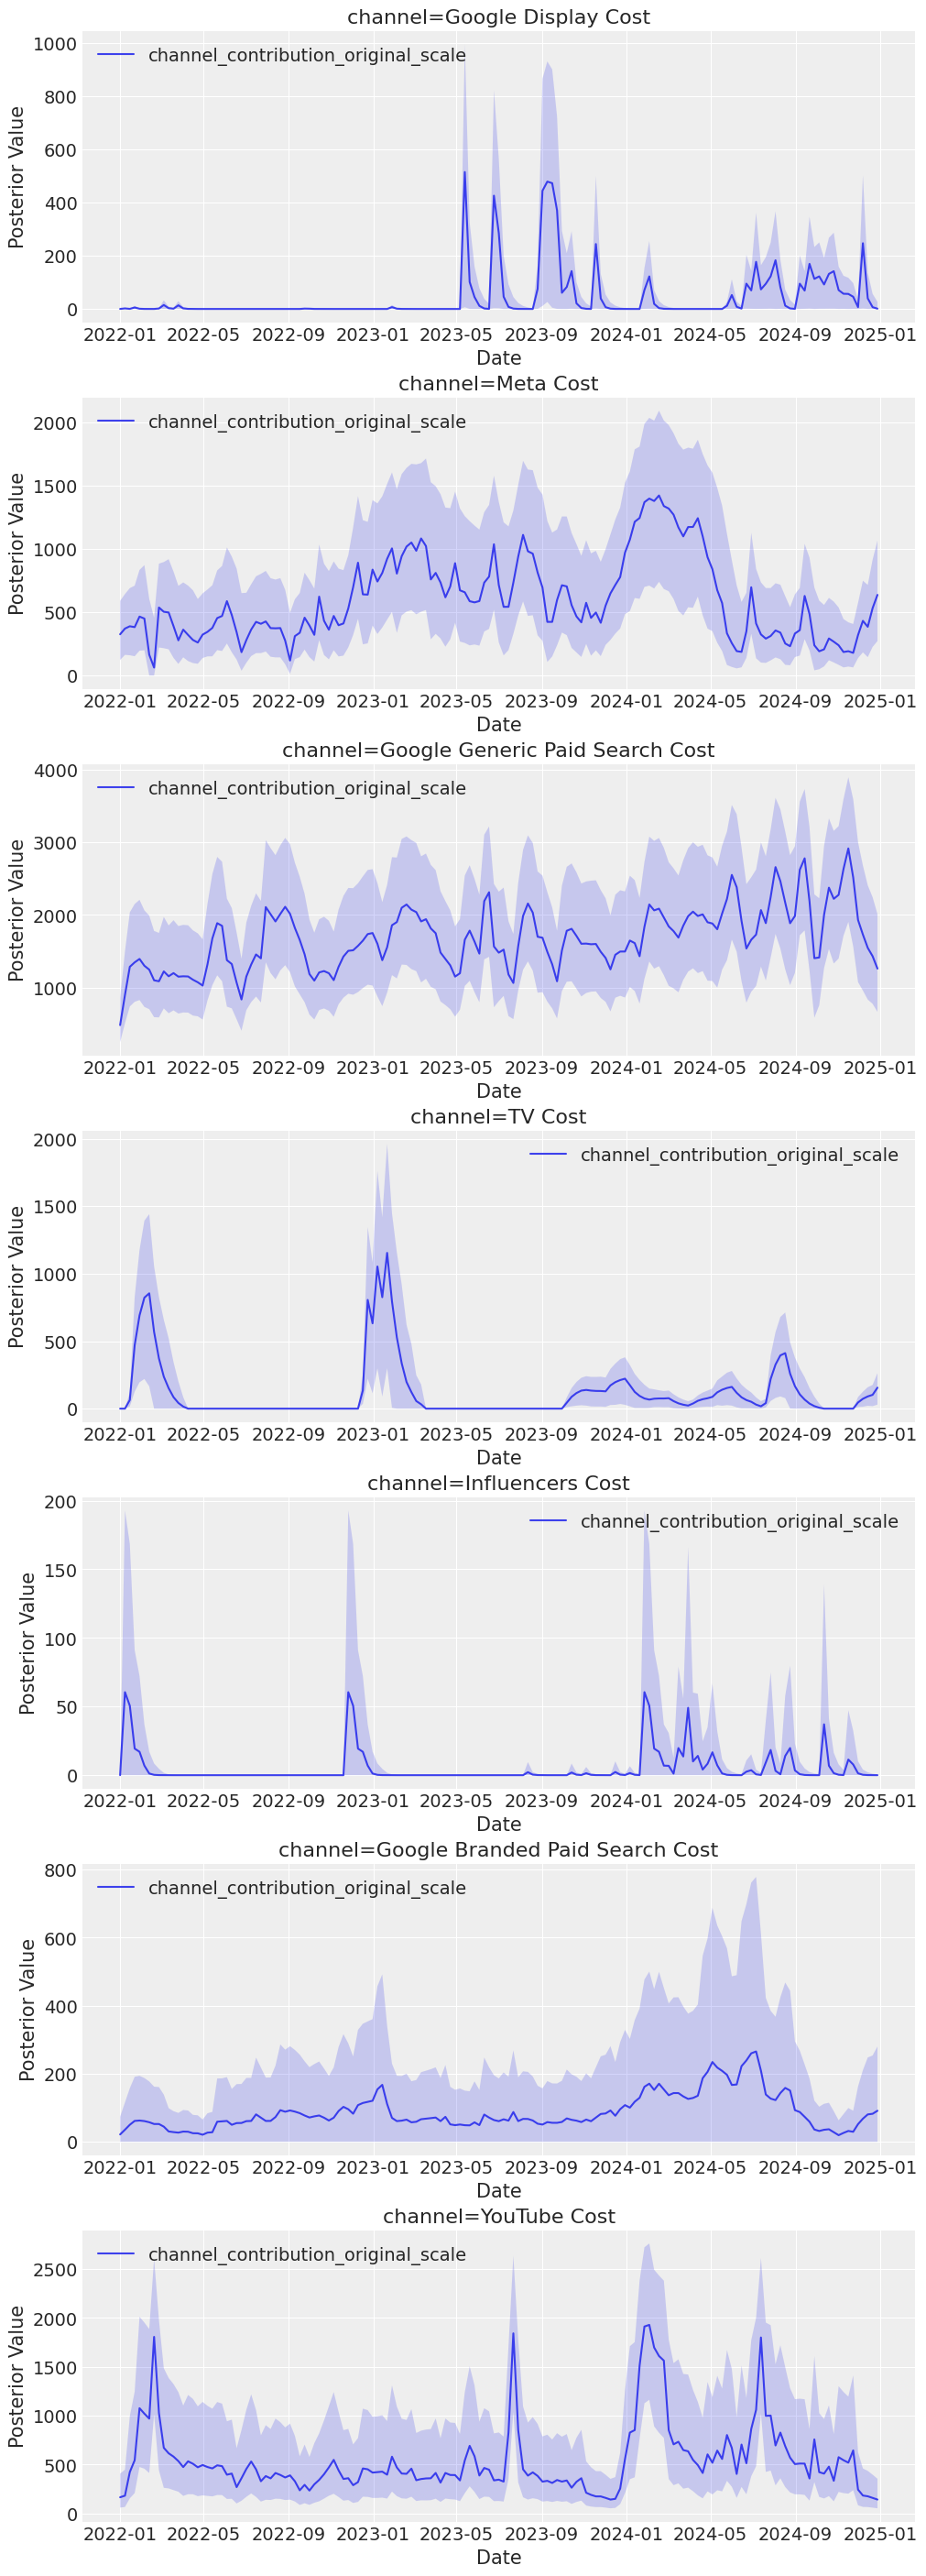

In [47]:
# Component contributions (original scale)

mmm.plot.contributions_over_time(
    var=["channel_contribution_original_scale"],
    hdi_prob=0.94,
);

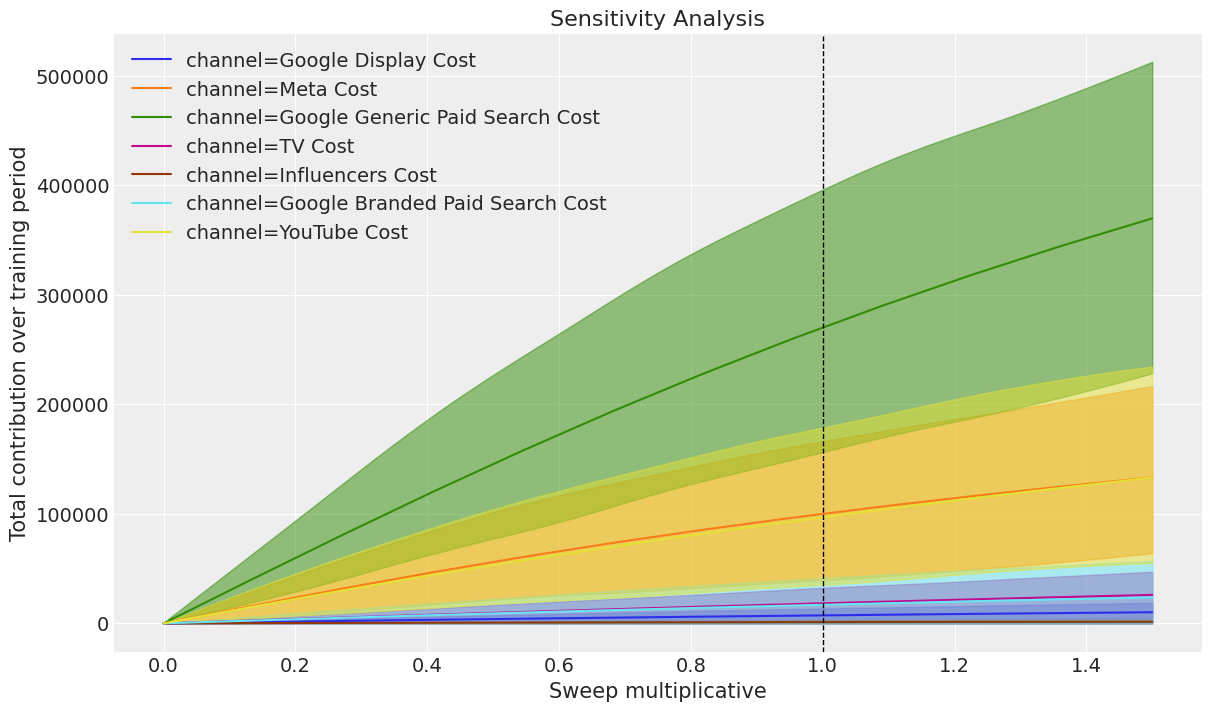

In [49]:
# Run sensitivity analysis i.e. marginal analysis sweep, based on % of actual spend (1 = 100% i.e. total actual spend)

sweeps = np.linspace(0, 1.5, 12)
mmm.sensitivity.run_sweep(
    sweep_values=sweeps,
    var_input="channel_data",
    var_names="channel_contribution_original_scale",
    extend_idata=True,
)

# Plot sensitivity analysis
ax = mmm.plot.sensitivity_analysis(
    xlabel="Sweep multiplicative",
    ylabel="Total contribution over training period",
    hue_dim="channel",
    x_sweep_axis="relative",
)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1);

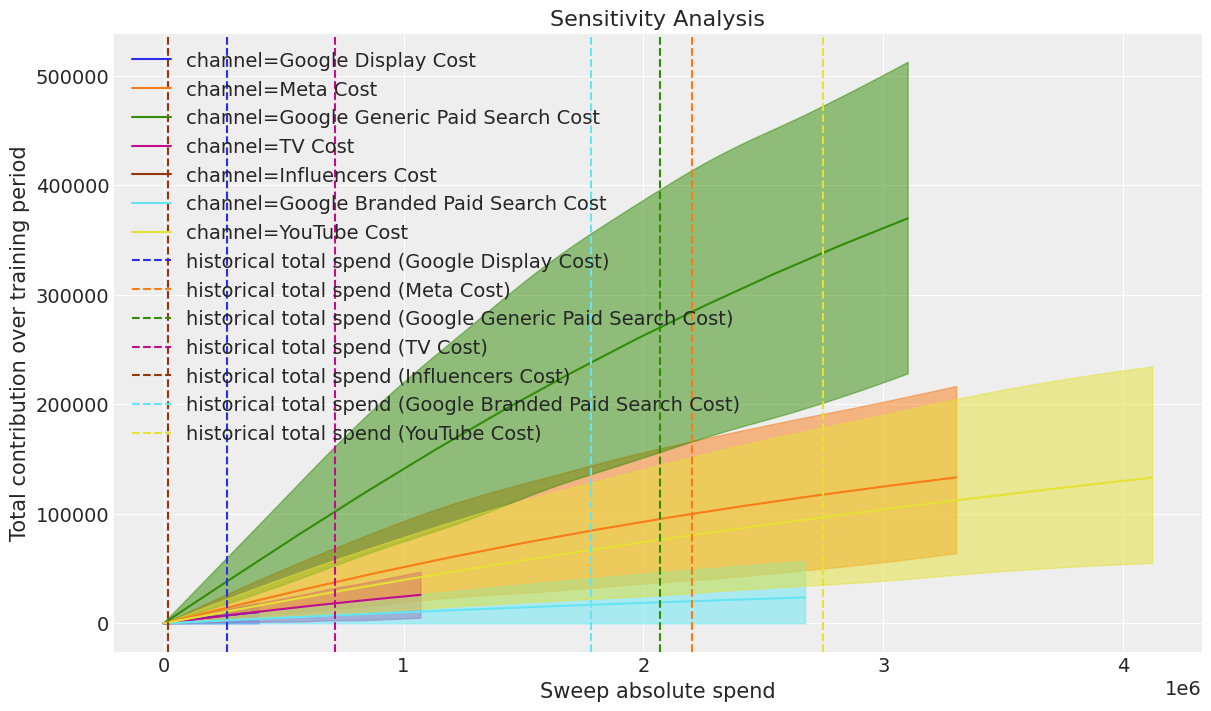

In [61]:
# Sensitivity analysis with absolute x-axis - dotted line = actual spend values

ax = mmm.plot.sensitivity_analysis(
    xlabel="Sweep absolute spend",
    ylabel="Total contribution over training period",
    hue_dim="channel",
    x_sweep_axis="absolute",
)

for i, channel in enumerate(channels):
    ax.axvline(
        X[channel].sum(),
        color=f"C{i}",
        linestyle="--",
        label=f"historical total spend ({channel})",
    )

ax.legend(loc="upper left");

# OOS

In [62]:
# extrapolate data for future dates

last_date = X["date"].max()

# New dates starting from last in dataset
n_new = 5
new_dates = pd.date_range(start=last_date, periods=1 + n_new, freq="W-MON")[1:]

X_out_of_sample = pd.DataFrame(
    {
        "date": new_dates,
    }
)

# Same channel spends as last day
for channel in channels:
    X_out_of_sample[channel] = X[channel].iloc[-1]

# Other features
X_out_of_sample["Dates_School_Holidays"] = 0
X_out_of_sample["Competitors Promotion"] = X["Competitors Promotion"].iloc[-1]
X_out_of_sample["Promotion"] = X["Promotion"].iloc[-1]

X_out_of_sample["t"] = range(len(X), len(X) + n_new)

X_out_of_sample

,date,Google Display Cost,Meta Cost,Google Generic Paid Search Cost,TV Cost,Influencers Cost,Google Branded Paid Search Cost,YouTube Cost,Dates_School_Holidays,Competitors Promotion,Promotion,t
0,2025-01-06,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,157
1,2025-01-13,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,158
2,2025-01-20,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,159
3,2025-01-27,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,160
4,2025-02-03,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,161


In [63]:
X_out_of_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             5 non-null      datetime64[ns]
 1   Google Display Cost              5 non-null      float64       
 2   Meta Cost                        5 non-null      float64       
 3   Google Generic Paid Search Cost  5 non-null      float64       
 4   TV Cost                          5 non-null      float64       
 5   Influencers Cost                 5 non-null      float64       
 6   Google Branded Paid Search Cost  5 non-null      float64       
 7   YouTube Cost                     5 non-null      float64       
 8   Dates_School_Holidays            5 non-null      int64         
 9   Competitors Promotion            5 non-null      float64       
 10  Promotion                        5 non-null      float64       
 1

In [64]:
# forecast 'y' based on model coefficients and extrapolated dates

y_out_of_sample = mmm.sample_posterior_predictive(X_out_of_sample, extend_idata=False)
y_out_of_sample

Output()

<xarray.Dataset> Size: 416kB
Dimensions:           (date: 5, sample: 4000)
Coordinates:
  * date              (date) datetime64[ns] 40B 2025-01-06 ... 2025-02-03
  * sample            (sample) object 32kB MultiIndex
  * chain             (sample) int64 32kB 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw              (sample) int64 32kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    y                 (date, sample) float64 160kB 0.3521 0.4255 ... 0.5079
    y_original_scale  (date, sample) float64 160kB 3.579e+03 ... 5.162e+03
Attributes:
    created_at:                 2026-05-08T13:53:56.191345+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4

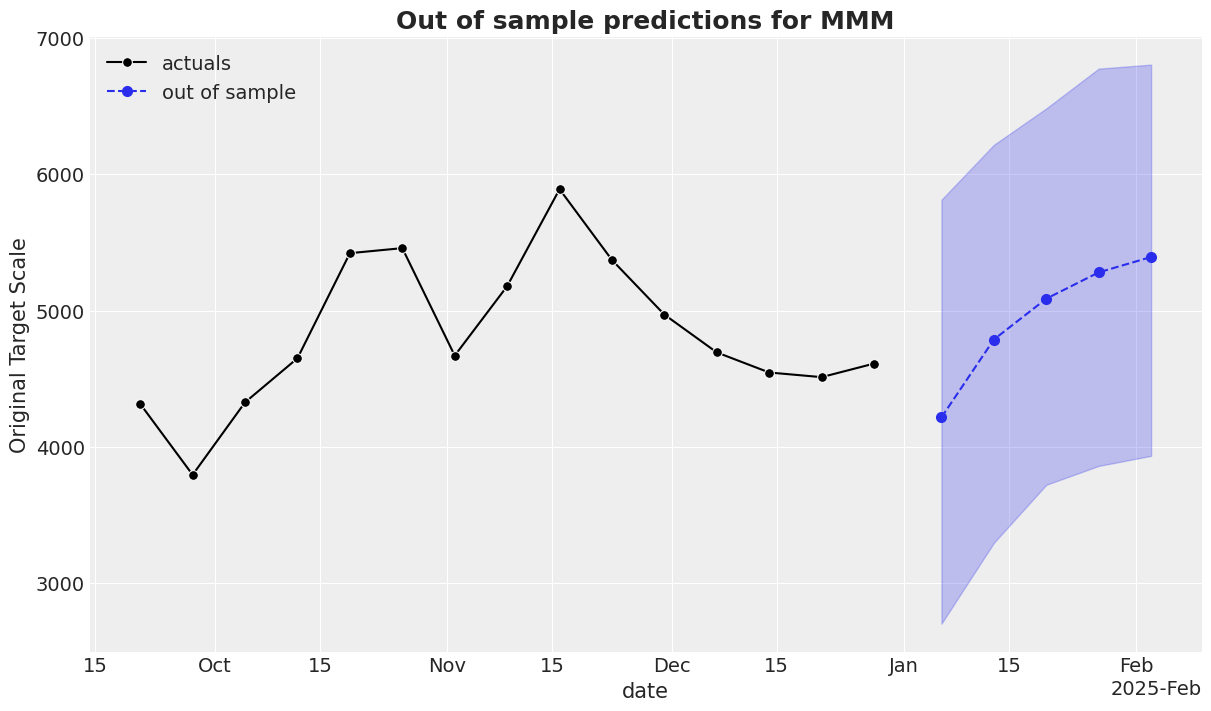

In [65]:
# plot forecasted 'y' alongside actual 'y'

def plot_in_sample(X, y, ax, n_points: int = 15):
    sns.lineplot(
        x=X["date"][-n_points:],
        y=y[-n_points:],
        marker="o",
        markersize=7,
        color="black",
        label="actuals",
        ax=ax,
    )
    return ax


def plot_out_of_sample(X_out_of_sample, y_out_of_sample, ax, color, label):
    y_out_original_scale = (
        y_out_of_sample["y_original_scale"].unstack().transpose(..., "date")
    )
    az.plot_hdi(
        X_out_of_sample["date"].dt.to_pydatetime(),
        y_out_original_scale,
        smooth=False,
        fill_kwargs={"alpha": 0.25, "color": color},
        ax=ax,
    )

    mean = y_out_original_scale.mean(dim=("chain", "draw"))
    mean.plot(ax=ax, marker="o", markersize=7, label=label, color=color, linestyle="--")
    ax.set(ylabel="Original Target Scale")
    ax.set_title("Out of sample predictions for MMM", fontsize=18, fontweight="bold")
    return ax


_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax)
plot_out_of_sample(
    X_out_of_sample, y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
ax.legend(loc="upper left");

In [66]:
# forecast 'y' including adstock carryover

y_out_of_sample_with_adstock = mmm.sample_posterior_predictive(
    X_out_of_sample, extend_idata=False, include_last_observations=True
)

Output()

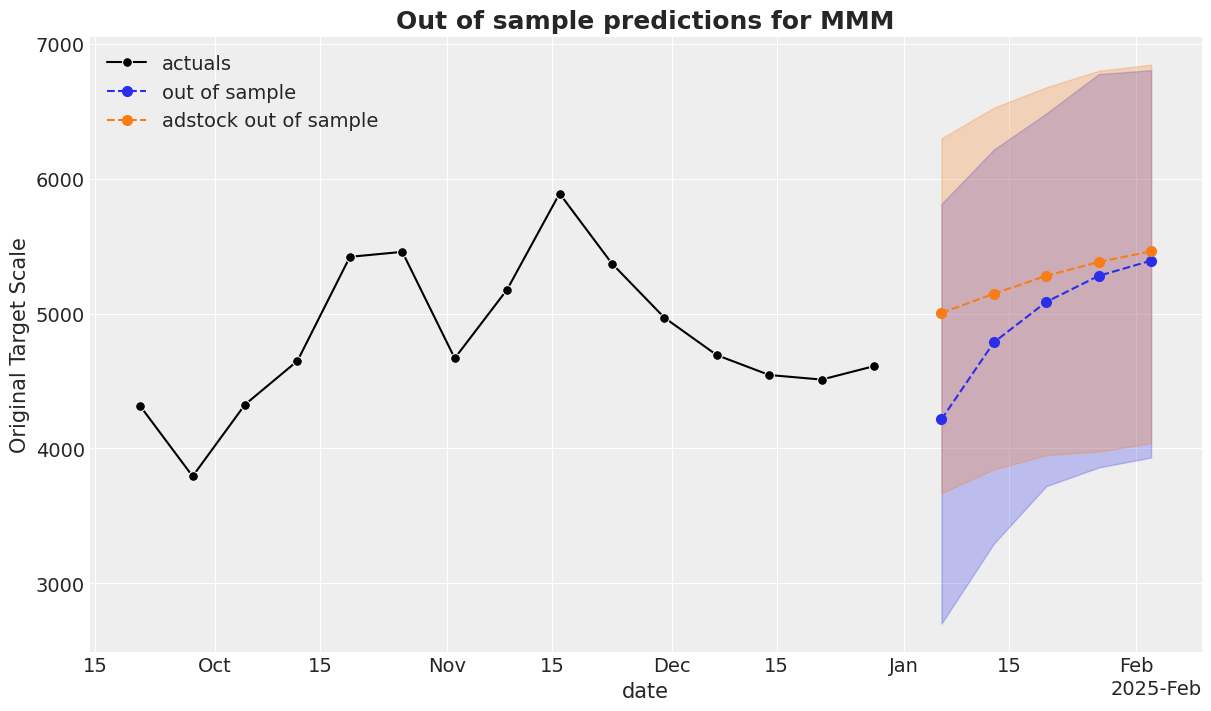

In [67]:
# plot new 'y' with previous prediction and actual 'y'

_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax)
plot_out_of_sample(
    X_out_of_sample, y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
plot_out_of_sample(
    X_out_of_sample,
    y_out_of_sample_with_adstock,
    ax=ax,
    label="adstock out of sample",
    color="C1",
)
ax.legend();